In [1]:
pip install dataretrieval

  Using cached dataretrieval-1.1.2-py3-none-any.whl.metadata (13 kB)
Using cached dataretrieval-1.1.2-py3-none-any.whl (62 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import pyproj
import osmnx as ox
import folium
import contextily as ctx
import dataretrieval.nwis as nwis # use to pull from USGS
from shapely.geometry import Point
import requests

In [3]:
# create geodataframe of Olympic National Park boundaries
onp = "Olympic National Park, Washington, USA"
onp_gdf = ox.geocode_to_gdf(onp)

# create geodataframe of ONP Trails within park boundaries
trails_gdf = ox.features.features_from_polygon(onp_gdf.geometry.iloc[0], {'highway': 'path'})

In [4]:
# convert to UTM 10N crs
onp_gdf = onp_gdf.to_crs('EPSG: 32610')
trails_gdf = trails_gdf.to_crs('EPSG: 32610')

In [5]:
# create geodataframe of ONP and surrounding area Rivers
# maybe better to use open street maps?

# calling in the data from the Nationwide River Inventory (NRI) 
# used AI to help with API. It added the params and request part since calling in the url only brought in 1000 rivers, which didn't include those in ONP
rivers_url = "https://services1.arcgis.com/fBc8EJBxQRMcHlei/arcgis/rest/services/Nationwide_Rivers_Inventory_Official/FeatureServer/0/query"

params = {
    "where": """Management_Area_Name IN ('Olympic National Park', 'Olympic National Forest', 'Olympic National Park, Olympic National Forest',
                'The Brothers Wilderness')
            OR River LIKE '%Bogachiel%'""",
        "outFields": "*",
        "f": "geojson"}

r = requests.get(rivers_url, params=params)
rivers_gdf = gpd.read_file(r.text)

# convert to UTM 10N crs
rivers_gdf = rivers_gdf.to_crs('EPSG:32610')

In [6]:
# create a geodataframe of USGS stations
# add USGS station locations - code from streamflow notebook

station_id = stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000]
stations_gdf = gpd.GeoDataFrame(station_id, columns=['station_id'])
stations_gdf.index = ['Elwha River', 'Duckabush River', 'NF Skokomish River', 'Quinault River', 'Bogachiel River', 'Hoh River',
                    'Queets River', 'Calawah River', 'Dungeness River']
geom = []
# the 'dec_lat_va' and 'dec_long_va' were taken from AI since it was helping to navigate the USGS API
for station in station_id:
    coords = nwis.get_record(sites=str(station), service="site")
    lat = coords.iloc[0]['dec_lat_va'] 
    lon = coords.iloc[0]['dec_long_va']
    geom.append(Point(lon, lat))
    
stations_gdf['geometry'] = geom
stations_gdf.set_geometry(stations_gdf['geometry'])
# set crs given on the USGS site
stations_gdf = stations_gdf.set_crs('EPSG:4267')
# convert to UTM 10N crs
stations_gdf = stations_gdf.to_crs('EPSG:32610')

/tmp/ipykernel_221/3075810099.py:16: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  stations_gdf['geometry'] = geom


In [42]:
# tried pulling from the API, but was unsuccessful after ~ an hour of troubleshooting, so I elected to just download the file

watersheds_gdf = gpd.read_file("data/NHD_-9030064575332258501.geojson")
watersheds_gdf = watersheds_gdf.to_crs(onp_gdf.crs)

In [8]:
# set x and y limits of the plot
bounds = onp_gdf.total_bounds
xmin, xmax, ymin, ymax = bounds[0], bounds[2], bounds[1], bounds[3]
buffer = 10000

In [9]:
# I was unable to add the ONP boundary to the plot's legend, this fix from a github discussion forum: https://github.com/geopandas/geopandas/issues/660

from matplotlib.legend import Legend
from matplotlib.collections import PatchCollection
from matplotlib.legend_handler import HandlerPolyCollection

Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})

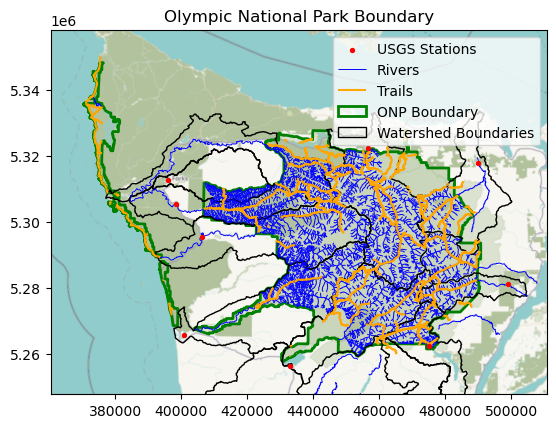

In [43]:
fig, ax = plt.subplots()

stations_gdf.plot(ax=ax, marker='o', markersize = 8, color='red', zorder=5, label='USGS Stations')
rivers_gdf.plot(ax=ax, color='blue', linewidth=0.7, zorder=3, label='Rivers')
trails_gdf.plot(ax=ax, color='orange', zorder=4, label='Trails')
onp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', linewidth=2, zorder=1, label='ONP Boundary')
watersheds_gdf.plot(ax=ax, facecolor='None', edgecolor='k', linewidth=1, zorder=2, label='Watershed Boundaries')
ax.set_title("Olympic National Park Boundary")
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
# ax.grid(True)
ax.set_xlim(xmin-buffer, xmax+2*buffer)
ax.set_ylim(ymin-buffer, ymax+buffer)
ax.legend()